In [77]:
print("name : Misty Jangid")
print("Roll number: 202401100500106")
print("name : Milind Pushp")
print("Roll number: 202401100500105")

name : Misty Jangid
Roll number: 202401100500106
name : Milind Pushp
Roll number: 202401100500105


In [5]:
import pandas as pd

In [7]:
column_names = [f"feature_{i}" for i in range(57)] + ["label"] 

In [9]:
df = pd.read_csv("spambase.data", header=None, names=column_names) 

In [11]:
df.head() 

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_48,feature_49,feature_50,feature_51,feature_52,feature_53,feature_54,feature_55,feature_56,label
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [13]:
print(df.shape)
df.info() 

(4601, 58)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   feature_0   4601 non-null   float64
 1   feature_1   4601 non-null   float64
 2   feature_2   4601 non-null   float64
 3   feature_3   4601 non-null   float64
 4   feature_4   4601 non-null   float64
 5   feature_5   4601 non-null   float64
 6   feature_6   4601 non-null   float64
 7   feature_7   4601 non-null   float64
 8   feature_8   4601 non-null   float64
 9   feature_9   4601 non-null   float64
 10  feature_10  4601 non-null   float64
 11  feature_11  4601 non-null   float64
 12  feature_12  4601 non-null   float64
 13  feature_13  4601 non-null   float64
 14  feature_14  4601 non-null   float64
 15  feature_15  4601 non-null   float64
 16  feature_16  4601 non-null   float64
 17  feature_17  4601 non-null   float64
 18  feature_18  4601 non-null   float64
 19  feature_19  4601

In [15]:
df['label'].value_counts() 

label
0    2788
1    1813
Name: count, dtype: int64

In [17]:
df = df.drop_duplicates() 

In [19]:
df = df.fillna(df.median(numeric_only=True)) 

In [55]:
X = df.drop("label", axis=1) 
y = df["label"]

In [23]:
from sklearn.model_selection import train_test_split 

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [29]:
from sklearn.preprocessing import StandardScaler

In [31]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

In [35]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "SVM (Linear)": SVC(kernel="linear", probability=True),
    "SVM (RBF Kernel)": SVC(kernel="rbf", probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB()
}

results = {}

In [37]:
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"{name} Accuracy: {acc*100:.2f}%")

Logistic Regression Accuracy: 93.47%
SVM (Linear) Accuracy: 93.59%
SVM (RBF Kernel) Accuracy: 93.23%
Random Forest Accuracy: 94.30%
KNN Accuracy: 91.33%
Naive Bayes Accuracy: 82.90%


In [39]:
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print("\nBest Model:", best_model_name)


Best Model: Random Forest


In [41]:
y_pred_best = best_model.predict(X_test_scaled)

In [57]:
from sklearn.metrics import accuracy_score, confusion_matrix 

In [59]:
from sklearn.metrics import confusion_matrix, classification_report

In [61]:
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_best))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best))


Confusion Matrix:
 [[485  21]
 [ 27 309]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.96      0.95       506
           1       0.94      0.92      0.93       336

    accuracy                           0.94       842
   macro avg       0.94      0.94      0.94       842
weighted avg       0.94      0.94      0.94       842



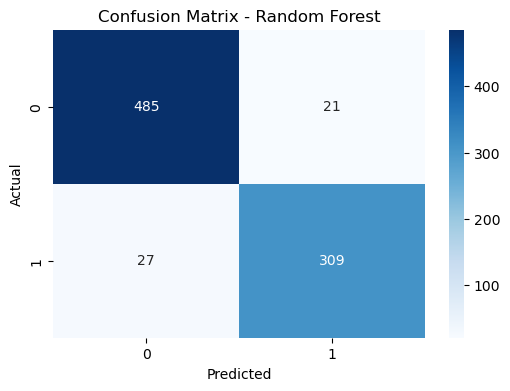

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [65]:
import matplotlib.pyplot as plt
import numpy as np

In [67]:
actual = y_test.values[:50]
pred = y_pred_best[:50]

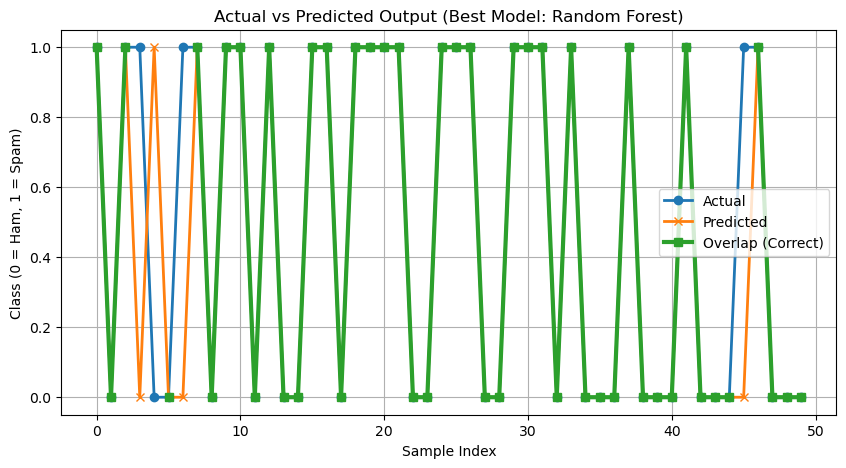

In [69]:
overlap = np.where(actual == pred, actual, np.nan)

plt.figure(figsize=(10,5))

plt.plot(actual, linewidth=2, label="Actual", marker="o")
plt.plot(pred, linewidth=2, label="Predicted", marker="x")
plt.plot(overlap, linewidth=3, label="Overlap (Correct)", marker="s")

plt.title(f"Actual vs Predicted Output (Best Model: {best_model_name})")
plt.xlabel("Sample Index")
plt.ylabel("Class (0 = Ham, 1 = Spam)")
plt.legend()
plt.grid(True)
plt.show()

In [81]:
print("name : Misty Jangid")
print("Roll number: 202401100500106")
print("name : Milind Pushp")
print("Roll number: 202401100500105")

name : Misty Jangid
Roll number: 202401100500106
name : Milind Pushp
Roll number: 202401100500105
